In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

df = pd.read_csv("hiring.csv")
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [3]:
exp_map = {
    "zero":0, "one":1, "two":2, "three":3, "four":4,
    "five":5, "six":6, "seven":7, "eight":8, "nine":9, "ten":10
}

df.experience = df.experience.map(exp_map)

In [4]:
df.experience = df.experience.fillna(0)

df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(
    df['test_score(out of 10)'].median()
)

In [5]:
X = df[['experience','test_score(out of 10)','interview_score(out of 10)']]
y = df['salary($)']

In [6]:
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
model.predict(pd.DataFrame([[2,9,6]], columns=X.columns))

array([62565.05576208])

In [8]:
model.predict(pd.DataFrame([[12,10,10]], columns=X.columns))

array([63653.03593556])

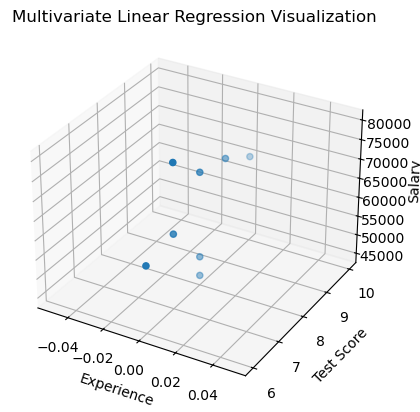

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['experience'],
           df['test_score(out of 10)'],
           df['salary($)'])

ax.set_xlabel("Experience")
ax.set_ylabel("Test Score")
ax.set_zlabel("Salary")

plt.title("Multivariate Linear Regression Visualization")
plt.show()

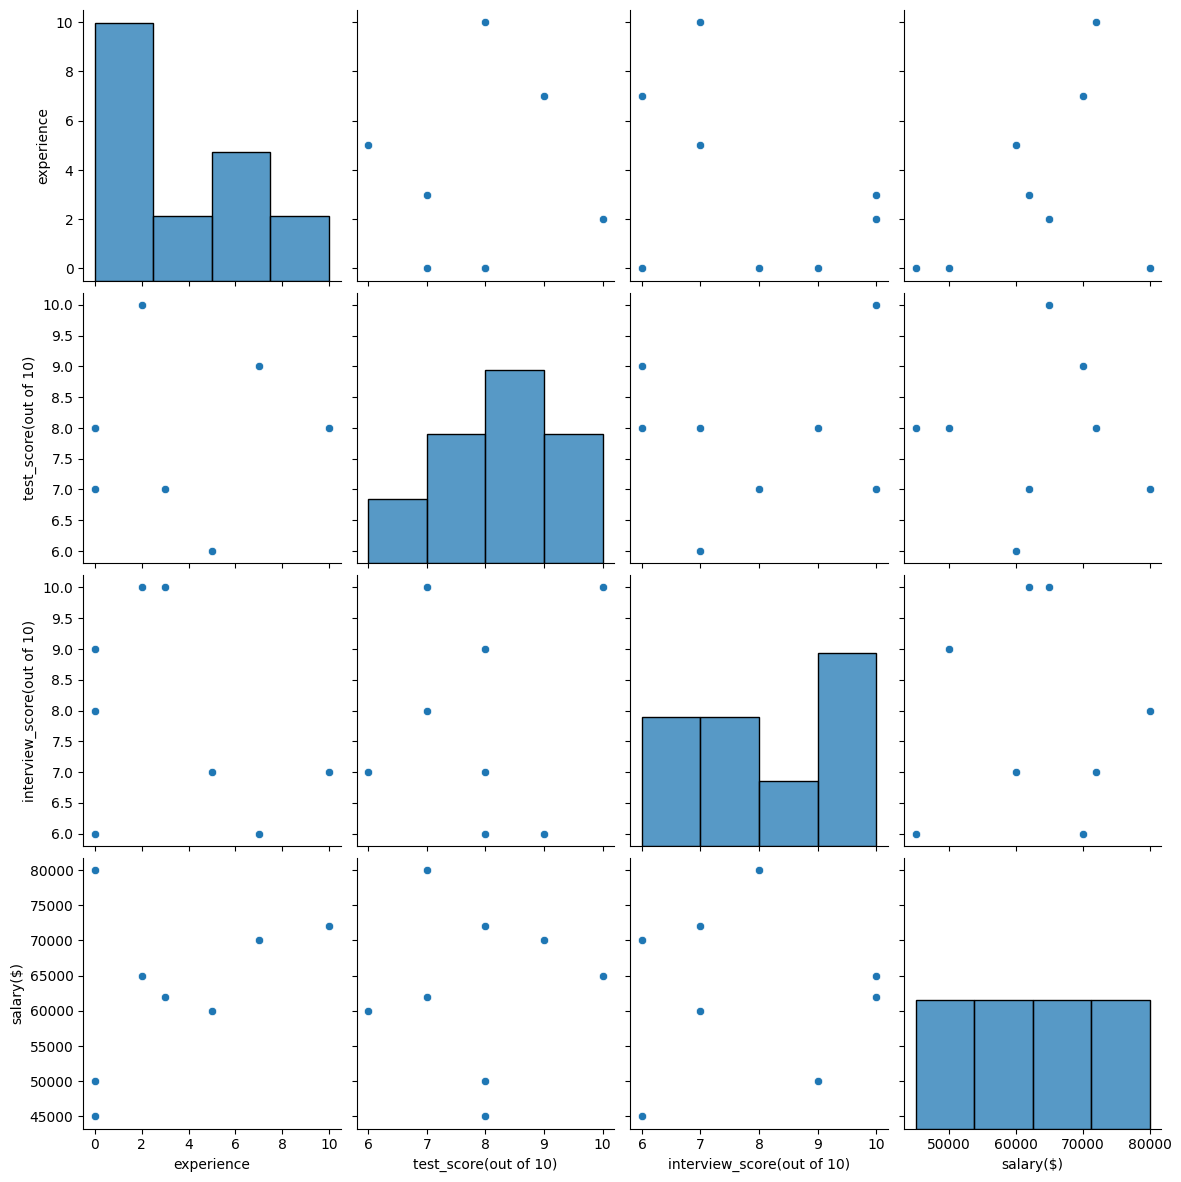

In [13]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.pairplot(df, height=3)
plt.show()

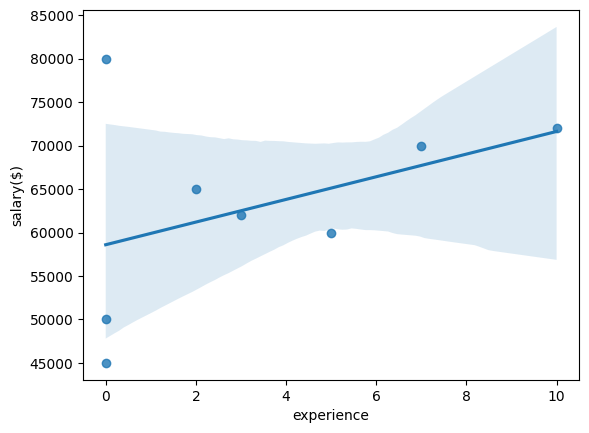

In [14]:
sns.regplot(x="experience", y="salary($)", data=df)
plt.show()